# Analyze the HNSCC dataset with epicore

In [2]:
import re
import sys
import pandas as pd
import subprocess
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap, BoundaryNorm
import matplotlib.patches as mpatches
import matplotlib.pyplot as plt
from Bio import SeqIO
import json
sys.path.append('../functions')
from peptide_annotator import proteome_to_dict, add_positions
from data_inspection import length_distribution
from waterfall import sequence_flow, plot_flow_all
import ast

### Prepare the data for epicore

In [2]:
# prepare fasta
proteome_dict = {}
proteome = SeqIO.parse(open('/mnt/volume/jana/thesis/data/spHUMANwoi_202102_HPV_201801.fasta'),'fasta')
for protein in proteome:
    proteome_dict[protein.id.split('|')[1]] = str(protein.seq)

with open('prepared_fasta.fasta','w') as prepared_fasta:
    for identifier, sequence in proteome_dict.items():
        prepared_fasta.write(f'>{identifier}\n')
        splitted_seq = [sequence[i:i+60] for i in range(0, len(sequence), 60)]
        for line in splitted_seq:
            prepared_fasta.write(f'{line}\n')

In [3]:
# load data
peptide_df = pd.read_excel('/mnt/volume/jana/thesis/data/20260118_HNSCC_Datensatz_Schroeder.xlsx')
peptide_df['sample'] = peptide_df.apply(lambda row: re.sub(r'^;*|;*$','',f"{row['Class_I_benign_donor']};{row['Class_I_HNSCC_donor']};{row['Class_II_benign_donor']};{row['Class_II_HNSCC_donor']}".replace('nan','')).replace(';;',';'), axis=1)
peptide_df['class'] = peptide_df.apply(lambda row: re.sub(r'^;*|;*$','',f"{';'.join(['I' for i in range(len(row['Class_I_benign_donor'].split(';')) if type(row['Class_I_benign_donor'])!=float else 0)])};{';'.join(['I' for i in range(len(row['Class_I_HNSCC_donor'].split(';')) if type(row['Class_I_HNSCC_donor'])!=float else 0)])};{';'.join(['II' for i in range(len(row['Class_II_benign_donor'].split(';')) if type(row['Class_II_benign_donor'])!=float else 0)])};{';'.join(['II' for i in range(len(row['Class_II_HNSCC_donor'].split(';')) if type(row['Class_II_HNSCC_donor'])!=float else 0)])}".replace('nan','')).replace(';;',';'), axis=1)
peptide_df['sample'] = peptide_df['sample'].apply(lambda cell: cell.split(';'))
peptide_df['class'] = peptide_df['class'].apply(lambda cell: cell.split(';'))
peptide_df['uniprot_ID'] = peptide_df['uniprot_ID'].str.split(';')
peptide_df_exploded = peptide_df.explode('uniprot_ID')


# annotate peptides
peptide_df_exploded = peptide_df_exploded[~peptide_df_exploded['uniprot_ID'].isnull()]
proteome_dict = proteome_to_dict('prepared_fasta.fasta')
peptide_df_exploded = add_positions(proteome_dict, peptide_df_exploded,'uniprot_ID','sequence')
peptide_df_exploded = peptide_df_exploded.explode(['sample','class'])
peptide_df_exploded['condition'] = peptide_df_exploded['sample'].apply(lambda sample: 'benign' if 'HNSCC' not in sample else 'malignant')
peptide_df_exploded = peptide_df_exploded[['sequence','accessions','sample', 'condition','start','end','class']]
peptide_df_exploded[peptide_df_exploded['class']=='I'].to_csv('class1_peptides.csv')
peptide_df_exploded[peptide_df_exploded['class']=='II'].to_csv('class2_peptides.csv')
peptide_df_exploded['condition'] = peptide_df_exploded.apply(lambda row: row['condition']+'~'+row['class'], axis=1)
peptide_df_exploded.to_csv('combined_peptides.csv')

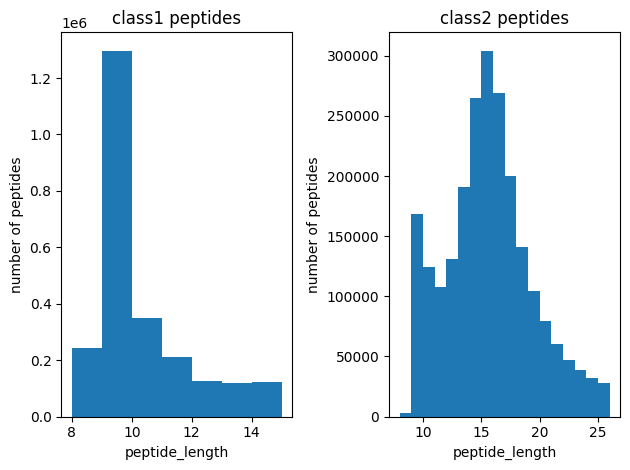

In [4]:
length_distribution(peptide_df_exploded[peptide_df_exploded['class']=='I'][['sequence','accessions','start','end']],peptide_df_exploded[peptide_df_exploded['class']=='II'][['sequence','accessions','start','end']])

In [5]:
print(f"The dataset comprises {len(peptide_df_exploded[(peptide_df_exploded['class']=='I')&(peptide_df_exploded['sample'].str.contains('_TU'))]['sample'].unique())} malignant class I samples.")
print(f"The dataset comprises {len(peptide_df_exploded[(peptide_df_exploded['class']=='II')&(peptide_df_exploded['sample'].str.contains('_TU'))]['sample'].unique())} malignant class II samples.")
print(f"The dataset comprises {len(peptide_df_exploded[(peptide_df_exploded['class']=='I')&(~peptide_df_exploded['sample'].str.contains('_TU'))]['sample'].unique())} benign class I samples.")
print(f"The dataset comprises {len(peptide_df_exploded[(peptide_df_exploded['class']=='II')&(~peptide_df_exploded['sample'].str.contains('_TU'))]['sample'].unique())} benign class II samples.")
print(f"The dataset comprises {len(peptide_df_exploded[(peptide_df_exploded['class']=='I')&(peptide_df_exploded['sample'].str.contains('_TU'))]['sequence'].unique())} (including ADJ {len(peptide_df_exploded[(peptide_df_exploded['class']=='I')&(peptide_df_exploded['condition'].str.contains('malignant'))]['sequence'].unique())}) unique malignant class I peptides.")
print(f"The dataset comprises {len(peptide_df_exploded[(peptide_df_exploded['class']=='II')&(peptide_df_exploded['sample'].str.contains('_TU'))]['sequence'].unique())} (including ADJ {len(peptide_df_exploded[(peptide_df_exploded['class']=='II')&(peptide_df_exploded['condition'].str.contains('malignant'))]['sequence'].unique())}) unique malignant class II peptides.")
print(f"The dataset comprises {len(peptide_df_exploded[(peptide_df_exploded['class']=='I')&(~peptide_df_exploded['sample'].str.contains('_TU'))]['sequence'].unique())} unique benign class I peptides.")
print(f"The dataset comprises {len(peptide_df_exploded[(peptide_df_exploded['class']=='II')&(~peptide_df_exploded['sample'].str.contains('_TU'))]['sequence'].unique())} unique benign class II peptides.")

The dataset comprises 40 malignant class I samples.
The dataset comprises 40 malignant class II samples.
The dataset comprises 396 benign class I samples.
The dataset comprises 377 benign class II samples.
The dataset comprises 90182 (including ADJ 96384) unique malignant class I peptides.
The dataset comprises 97288 (including ADJ 114451) unique malignant class II peptides.
The dataset comprises 307598 unique benign class I peptides.
The dataset comprises 309678 unique benign class II peptides.


### Run epicore

In [3]:
subprocess.run(['epicore', '--reference_proteome', 'prepared_fasta.fasta', '--out_dir', 'class1', 'generate-epicore-csv', '--min_epi_length', '8', '--min_overlap', '8', '--seq_column', 'sequence', '--protacc_column', 'accessions', '--delimiter', ';', '--evidence_file', 'class1_peptides.csv', '--start_column', 'start', '--end_column', 'end', '--sample_column', 'sample', '--condition_column', 'condition', '--strict'])

CompletedProcess(args=['epicore', '--reference_proteome', 'prepared_fasta.fasta', '--out_dir', 'class1', 'generate-epicore-csv', '--min_epi_length', '8', '--min_overlap', '8', '--seq_column', 'sequence', '--protacc_column', 'accessions', '--delimiter', ';', '--evidence_file', 'class1_peptides.csv', '--start_column', 'start', '--end_column', 'end', '--sample_column', 'sample', '--condition_column', 'condition', '--strict'], returncode=0)

In [2]:
subprocess.run(['epicore', '--reference_proteome', 'prepared_fasta.fasta', '--out_dir', 'class1_included', 'generate-epicore-csv', '--min_epi_length', '8', '--min_overlap', '8', '--seq_column', 'sequence', '--protacc_column', 'accessions', '--delimiter', ';', '--evidence_file', 'class1_peptides.csv', '--start_column', 'start', '--end_column', 'end', '--sample_column', 'sample', '--condition_column', 'condition', '--included'])

CompletedProcess(args=['epicore', '--reference_proteome', 'prepared_fasta.fasta', '--out_dir', 'class1_included', 'generate-epicore-csv', '--min_epi_length', '8', '--min_overlap', '8', '--seq_column', 'sequence', '--protacc_column', 'accessions', '--delimiter', ';', '--evidence_file', 'class1_peptides.csv', '--start_column', 'start', '--end_column', 'end', '--sample_column', 'sample', '--condition_column', 'condition', '--included'], returncode=0)

In [4]:
subprocess.run(['epicore', '--reference_proteome', 'prepared_fasta.fasta', '--out_dir', 'class2', 'generate-epicore-csv', '--min_epi_length', '9', '--min_overlap', '9', '--seq_column', 'sequence', '--protacc_column', 'accessions', '--delimiter', ';', '--evidence_file', 'class2_peptides.csv', '--start_column', 'start', '--end_column', 'end', '--sample_column', 'sample', '--condition_column', 'condition', '--strict'])

CompletedProcess(args=['epicore', '--reference_proteome', 'prepared_fasta.fasta', '--out_dir', 'class2', 'generate-epicore-csv', '--min_epi_length', '9', '--min_overlap', '9', '--seq_column', 'sequence', '--protacc_column', 'accessions', '--delimiter', ';', '--evidence_file', 'class2_peptides.csv', '--start_column', 'start', '--end_column', 'end', '--sample_column', 'sample', '--condition_column', 'condition', '--strict'], returncode=0)

In [3]:
subprocess.run(['epicore', '--reference_proteome', 'prepared_fasta.fasta', '--out_dir', 'class2_included', 'generate-epicore-csv', '--min_epi_length', '9', '--min_overlap', '9', '--seq_column', 'sequence', '--protacc_column', 'accessions', '--delimiter', ';', '--evidence_file', 'class2_peptides.csv', '--start_column', 'start', '--end_column', 'end', '--sample_column', 'sample', '--condition_column', 'condition', '--included'])

CompletedProcess(args=['epicore', '--reference_proteome', 'prepared_fasta.fasta', '--out_dir', 'class2_included', 'generate-epicore-csv', '--min_epi_length', '9', '--min_overlap', '9', '--seq_column', 'sequence', '--protacc_column', 'accessions', '--delimiter', ';', '--evidence_file', 'class2_peptides.csv', '--start_column', 'start', '--end_column', 'end', '--sample_column', 'sample', '--condition_column', 'condition', '--included'], returncode=0)

### Identify candidates and investigate chosen candidates class2

In [4]:
def compute_frequencies(epitopes_csv, peptides_csv, allele_dict, allotype):
    '''Compute frequencies on peptide and peptide group levbel.

    Args:
        epitopes_csv: Path to csv containing peptide groups.
        peptides_csv: Path to csv containing peptides.
        allele_dict: Dictionary containing samples and their allotypes.
        allotype: The allotype of interest.

    Returns:
        A dataframe containing the frequencies of the peptide groups and their peptides.
    '''

    # compute peptide frequencies
    peptides_df = pd.read_csv(peptides_csv, index_col=[0])
    peptides_df['sample'] = peptides_df['sample'].apply(lambda sample: sample[:-3] if '_TU' in sample else sample)
    peptides_df['HLA'] = peptides_df['sample'].replace(allele_dict)
    peptides_df = peptides_df[peptides_df['HLA'].str.contains(allotype, regex=False)|(~peptides_df['sample'].str.contains('HNSCC', regex=False))]
    peptides_df = peptides_df[~peptides_df['sample'].str.contains('ADJ')]
    all_benign = len(peptides_df[peptides_df['condition']=='benign']['sample'].unique())
    all_malignant = len(peptides_df[(peptides_df['condition']=='malignant')&(~peptides_df['sample'].str.contains('ADJ'))]['sample'].unique())
    peptides_df = peptides_df.groupby('sequence').agg({'sample':list, 'condition':list}).reset_index()
    peptides_df['benign_frequency'] = peptides_df.apply(lambda row: len(set([f'{sample}_{condition}' for sample, condition in zip(row['sample'], row['condition']) if condition=='benign']))/all_benign,axis=1)
    peptides_df['malignant_frequency'] = peptides_df.apply(lambda row: len(set([f'{sample}_{condition}' for sample, condition in zip(row['sample'], row['condition']) if condition=='malignant']))/all_malignant,axis=1)
    
    # compute peptide group frequencies
    epicore_df = pd.read_csv(epitopes_csv, index_col=[0])
    epicore_df['grouped_peptides_sequence'] = epicore_df['grouped_peptides_sequence'].apply(lambda cell: ast.literal_eval(cell))
    epicore_df['grouped_peptides_sample'] = epicore_df['grouped_peptides_sample'].apply(lambda cell: ast.literal_eval(cell))
    epicore_df['grouped_peptides_condition'] = epicore_df['grouped_peptides_condition'].apply(lambda cell: ast.literal_eval(cell))
    epicore_df = epicore_df.explode(['grouped_peptides_sequence','grouped_peptides_sample','grouped_peptides_condition'])
    epicore_df = epicore_df[(epicore_df['grouped_peptides_sample'].apply(lambda sample: sample[:-3] if '_TU' in sample else sample).replace(allele_dict).str.contains(allotype, regex=False))|(~epicore_df['grouped_peptides_sample'].str.contains('HNSCC', regex=False))]
    epicore_df = epicore_df[~epicore_df['grouped_peptides_sample'].str.contains('ADJ')]
    epicore_df = pd.merge(epicore_df, peptides_df[['sequence','benign_frequency','malignant_frequency']], left_on='grouped_peptides_sequence',right_on='sequence', how='outer')
    epicore_df = epicore_df.groupby(['whole_epitopes','consensus_epitopes']).agg({'benign_frequency':'max', 'malignant_frequency':'max','grouped_peptides_sample':list,'grouped_peptides_condition':list, 'grouped_peptides_sequence':list})
    epicore_df['benign_frequency_epicore'] = epicore_df.apply(lambda row: len(set([f'{sample}_{condition}' for sample, condition in zip(row['grouped_peptides_sample'], row['grouped_peptides_condition']) if condition=='benign']))/all_benign,axis=1)
    epicore_df['malignant_frequency_epicore'] = epicore_df.apply(lambda row: len(set([f'{sample}_{condition}' for sample, condition in zip(row['grouped_peptides_sample'], row['grouped_peptides_condition']) if condition=='malignant']))/all_malignant,axis=1)
    return epicore_df

def get_candidate_region(merged_df, malignant_threshold, benign_threshold):
    ''' Get candidate region of epicore results with certain threshold.

    Args:
        merged_df: A dataframe containing the frequencies on peptide and peptide
            group level. 
        malignant_threshold: The minimal malignant threshold for a peptide group 
            to be considered a candidate. 
        benign_threshold: The maximal benign threshold for a peptide group 
            to be considered a candidate. 
    
    '''
    return merged_df[(merged_df['benign_frequency_epicore']<=benign_threshold)&(merged_df['malignant_frequency_epicore']>=malignant_threshold)].copy()


def plot_candidates(candidates_df, axis):

    candidates_df.loc[:,'ratio'] = (candidates_df['benign_frequency_epicore'] + 0.000001) / (candidates_df['malignant_frequency_epicore'] + 0.000001)
    candidates_df = candidates_df.sort_values('ratio')
    x_vals = [i for i in range(len(candidates_df))]

    axis.bar(x_vals, candidates_df['malignant_frequency_epicore'], color='red', label='Epicore malignant')
    axis.bar(x_vals,candidates_df['malignant_frequency'], color='white')
    axis.bar(x_vals,candidates_df['malignant_frequency'], color='red', alpha=0.5, label='Peptide malignant')
    axis.bar(x_vals, -candidates_df['benign_frequency_epicore'], color='black', label='Epicore benign')
    axis.bar(x_vals, -candidates_df['benign_frequency'], color='white')
    axis.bar(x_vals,-candidates_df['benign_frequency'], color='black', alpha=0.5, label='Peptide benign')

    axis.set_ylim([-0.12,1])

def HNSCC_candidate_heatmap(epitopes_csv, candidate, ax):

    # get candidate group
    df = pd.read_csv(epitopes_csv)
    group = df[(df['whole_epitopes']==candidate)].iloc[0]
    group_df = pd.DataFrame({'sequence':ast.literal_eval(group['grouped_peptides_sequence']),'start': ast.literal_eval(group['grouped_peptides_start']),'end': ast.literal_eval(group['grouped_peptides_end']), 'samples': ast.literal_eval(group['grouped_peptides_sample'])})
    group_df = group_df.sort_values(['start','end'], ascending=[True, False])

    # build matrix for heatmap
    samples = ['tu'+s if 'TU' in s else 'be'+s for s in group_df['samples']]
    sequences = group_df['sequence']
    c = [f'{sample[2:]}_{sequence}' for sample, sequence in zip(samples, sequences)]
    matrix = np.zeros((len(set(sequences)), len(set(samples))))
    sample_i = sorted(list(set(samples)))
    sample_i = [s[2:] for s in sample_i]
    sequence_i =  group_df['sequence'].unique()

    for s_i, sample in enumerate(sample_i):
        for se_i, sequence in enumerate(sequence_i):
            if f'{sample}_{sequence}' in c:
                if 'TU' in sample:
                    matrix[se_i, s_i] = 1
                elif 'ADJ' in sample:
                    matrix[se_i, s_i] = -2
                else:
                    matrix[se_i, s_i] = -1
    

    cmap=ListedColormap(['#9a0200','#699d4c','none','#0a437a'])
    norm = [-2.1,-1.1,-0.2,0.2,1.1]
    norm = BoundaryNorm(norm, 4)
    im1 = ax.imshow(matrix, cmap=cmap, norm=norm,aspect='auto')
    ax.set_xticks([i for i in range(len(sample_i))], sample_i, rotation=90)
    ax.set_yticks([i for i in range(len(sequence_i))])
    aligned = [] 

    ww = [f'{seq}_{max(group_df["end"])-end}' for seq, end in zip(group_df['sequence'], group_df['end'])] 
        
    for s in sequence_i:
        for nusa in set(ww):
            if nusa.split('_')[0] == s:
                aligned.append('-'*len(s)+' '*int(nusa.split('_')[1]))
    ax.set_yticklabels(aligned, fontfamily='monospace')
    legend_elements = [mpatches.Patch(color='#0a437a',label='Malignant'),mpatches.Patch(color='#9a0200',label='ADJ'),mpatches.Patch(color='#699d4c',label='Benign')]
    ax.legend(handles=legend_elements, bbox_to_anchor=(1.5,0.5))


def id_rank_increase(df):
    # identify rank on peptide level
    df = df.sort_values(['malignant_frequency', 'benign_frequency'], ascending=[False, True])
    df['prev_malignant'] = df['malignant_frequency'].shift(-1)
    df['rank'] = df.apply(lambda row: 1 if row['prev_malignant']!=row['malignant_frequency'] else 0, axis=1)
    df['rank'] = df['rank'].cumsum()
    df['rank'] = df['rank'].shift(1)
    df.at[df.index[0],'rank'] = 0
    df = df.sort_values('ratio')
    df = df.sort_values(['malignant_frequency_epicore', 'benign_frequency_epicore'], ascending=[False, True])

    # identify rank on peptide group level
    df['prev_malignant'] = df['malignant_frequency_epicore'].shift(-1)
    df['rank_epicore'] = df.apply(lambda row: 1 if row['prev_malignant']!=row['malignant_frequency_epicore'] else 0, axis=1)
    df['rank_epicore'] = df['rank_epicore'].cumsum()
    df['rank_epicore'] = df['rank_epicore'].shift(1)

    # identify how many candidates have higher rank due to epicore
    df.at[df.index[0],'rank_epicore'] = 0
    print(f"{len(df[df['rank']>df['rank_epicore']])} peptide groups have higher prioritization due to epicore.")

In [3]:
# load allotypes
allotypes_df = pd.read_excel('/mnt/volume/jana/thesis/data/260117_PRIDE_registration_sheet.xlsx')
allotypes_df['sample'] = allotypes_df['factor value[co-process identifier]'].str.split('HNSCC')
allotypes_df['sample'] = allotypes_df['sample'].apply(lambda cell: cell[1].split('_'))
allotypes_df['sample'] = allotypes_df['sample'].apply(lambda cell: cell[1:3] if cell[0] == '' else cell[:2])
allotypes_df['sample'] = allotypes_df['sample'].apply(lambda cell: cell if len(cell[1])>=2 else [cell[0],'0'+cell[1]])
allotypes_df['sample'] = allotypes_df['sample'].apply(lambda cell: 'HNSCC' + '_'.join(cell))
allotypes_dict = dict(zip(allotypes_df['sample'],allotypes_df['characteristics[mhc type]'] ))

/tmp/ipykernel_678828/3058985238.py:15: DtypeWarning: Columns (0: end, 1: class) have mixed types. Specify dtype option on import or set low_memory=False.
  peptides_df = pd.read_csv(peptides_csv, index_col=[0])


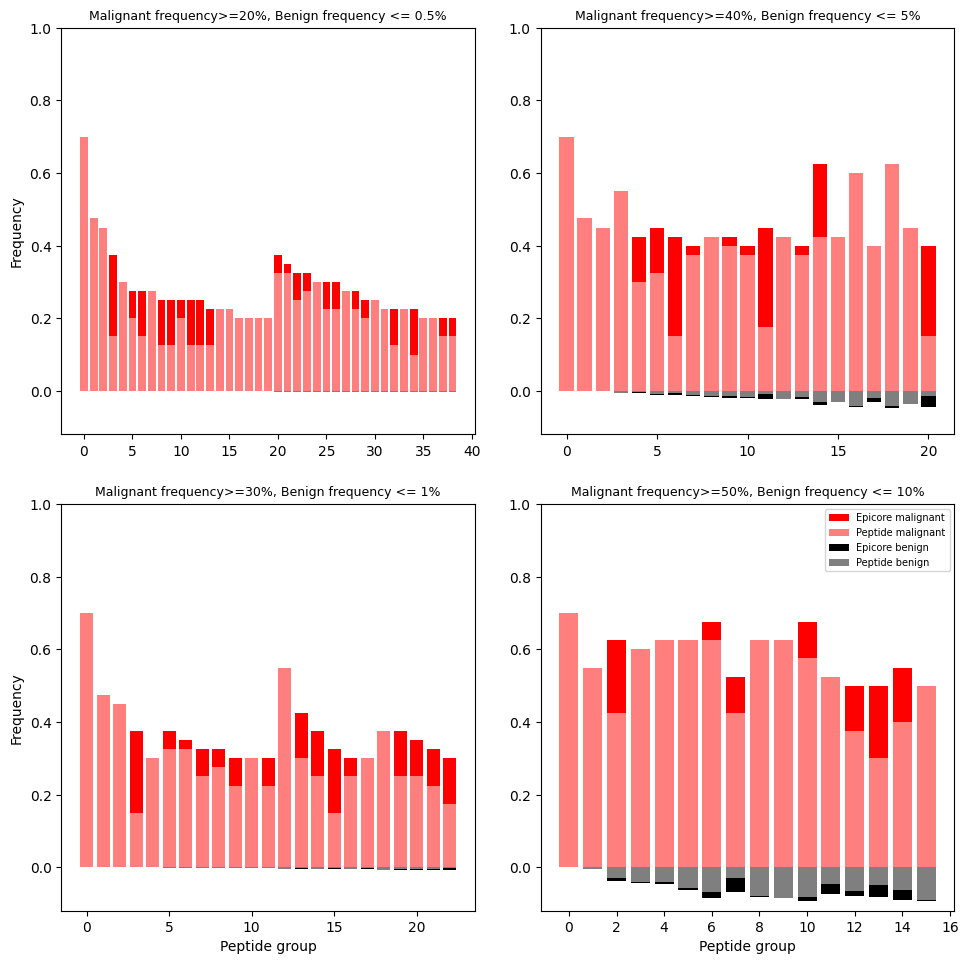

In [6]:
# Visualizise candidate region for different thresholds
epicore_df = compute_frequencies('class2_included/epitopes.csv', 'class2_peptides.csv', allotypes_dict, '')

fig, ax = plt.subplots(2,2, figsize=(10,10))
candidates1_df = get_candidate_region(epicore_df, 0.2, 0.005)
plot_candidates(candidates1_df, ax[0,0])
ax[0,0].set_title('Malignant frequency>=20%, Benign frequency <= 0.5%', fontdict={'fontsize':9})
ax[0,0].set_ylabel('Frequency')
#ax[0,0].tick_params(labelsize=5.5)

candidates2_df = get_candidate_region(epicore_df, 0.3, 0.01)
ax[1,0].set_title('Malignant frequency>=30%, Benign frequency <= 1%', fontdict={'fontsize':9})
plot_candidates(candidates2_df, ax[1,0])
ax[1,0].set_ylabel('Frequency')
ax[1,0].set_xlabel('Peptide group')

candidates3_df = get_candidate_region(epicore_df, 0.4, 0.05)
ax[0,1].set_title('Malignant frequency>=40%, Benign frequency <= 5%', fontdict={'fontsize':9})
plot_candidates(candidates3_df, ax[0,1])

candidates4_df = get_candidate_region(epicore_df, 0.5, 0.1)
ax[1,1].set_title('Malignant frequency>=50%, Benign frequency <= 10%', fontdict={'fontsize':9})
plot_candidates(candidates4_df, ax[1,1])
ax[1,1].set_xlabel('Peptide group')

plt.legend(fontsize=7)
plt.tight_layout(pad=2)
plt.savefig('figures/candidate_region.svg')

In [ ]:
# compute peptide frequencies
peptides_df = pd.read_csv('class2_peptides.csv', index_col=[0])
peptides_df['sample'] = peptides_df['sample'].apply(lambda sample: sample[:-3] if '_TU' in sample else sample)
peptides_df['HLA'] = peptides_df['sample'].replace(allotypes_dict)
peptides_df = peptides_df[peptides_df['HLA'].str.contains('', regex=False)|(~peptides_df['sample'].str.contains('HNSCC', regex=False))]
peptides_df = peptides_df[~peptides_df['sample'].str.contains('ADJ')]
all_benign = len(peptides_df[peptides_df['condition']=='benign']['sample'].unique())
all_malignant = len(peptides_df[(peptides_df['condition']=='malignant')&(~peptides_df['sample'].str.contains('ADJ'))]['sample'].unique())
peptides_df = peptides_df.groupby('sequence').agg({'sample':list, 'condition':list}).reset_index()
peptides_df['benign_frequency'] = peptides_df.apply(lambda row: len(set([f'{sample}_{condition}' for sample, condition in zip(row['sample'], row['condition']) if condition=='benign']))/all_benign,axis=1)
peptides_df['malignant_frequency'] = peptides_df.apply(lambda row: len(set([f'{sample}_{condition}' for sample, condition in zip(row['sample'], row['condition']) if condition=='malignant']))/all_malignant,axis=1)

# compute peptide group frequencies
frequency_df = pd.read_csv('class2_included/epitopes.csv', index_col=[0])
frequency_df['grouped_peptides_sequence'] = frequency_df['grouped_peptides_sequence'].apply(lambda cell: ast.literal_eval(cell))
frequency_df['grouped_peptides_sample'] = frequency_df['grouped_peptides_sample'].apply(lambda cell: ast.literal_eval(cell))
frequency_df['grouped_peptides_condition'] = frequency_df['grouped_peptides_condition'].apply(lambda cell: ast.literal_eval(cell))
frequency_df = frequency_df.explode(['grouped_peptides_sequence','grouped_peptides_sample','grouped_peptides_condition'])
frequency_df = frequency_df[(frequency_df['grouped_peptides_sample'].apply(lambda sample: sample[:-3] if '_TU' in sample else sample).replace(allotypes_dict).str.contains('', regex=False))|(~frequency_df['grouped_peptides_sample'].str.contains('HNSCC', regex=False))]
frequency_df = frequency_df[~frequency_df['grouped_peptides_sample'].str.contains('ADJ')]
frequency_df = frequency_df.groupby(['whole_epitopes','consensus_epitopes']).agg({'grouped_peptides_sample':list,'grouped_peptides_condition':list, 'grouped_peptides_sequence':list}).reset_index()
frequency_df['benign_frequency_epicore'] = frequency_df.apply(lambda row: len(set([f'{sample}_{condition}' for sample, condition in zip(row['grouped_peptides_sample'], row['grouped_peptides_condition']) if condition=='benign']))/all_benign,axis=1)
frequency_df['malignant_frequency_epicore'] = frequency_df.apply(lambda row: len(set([f'{sample}_{condition}' for sample, condition in zip(row['grouped_peptides_sample'], row['grouped_peptides_condition']) if condition=='malignant']))/all_malignant,axis=1)
frequency_df = frequency_df.explode(['grouped_peptides_sequence', 'grouped_peptides_sample', 'grouped_peptides_condition'])
frequency_df = pd.merge(frequency_df, peptides_df[['sequence','benign_frequency','malignant_frequency']], left_on='grouped_peptides_sequence',right_on='sequence', how='outer')

In [6]:
len(frequency_df[(frequency_df['benign_frequency_epicore']==0)&(frequency_df['malignant_frequency_epicore']>0)].drop_duplicates('whole_epitopes'))

5953

In [7]:

flows = sequence_flow(frequency_df, 'benign_frequency', 'benign_frequency_epicore', 'malignant_frequency' , 'malignant_frequency_epicore')
#plot_flow_all(flows)

In [8]:
plot_flow_all(flows)

In [13]:
len(epicore_df[(epicore_df['malignant_frequency_epicore']>=0.2)&(epicore_df['benign_frequency_epicore']==0)])

20

Identify how many peptides changed their rank for the different filter criteria.

In [14]:
print(f"There are {len(candidates1_df)} candidates for malignant frequency >=20% and benign frequency <=0.5%")
print(f"There are {len(candidates2_df)} candidates for malignant frequency >=30% and benign frequency <=1%")
print(f"There are {len(candidates3_df)} candidates for malignant frequency >=40% and benign frequency <=5%")
print(f"There are {len(candidates4_df)} candidates for malignant frequency >=50% and benign frequency <=10%")

There are 39 candidates for malignant frequency >=20% and benign frequency <=0.5%
There are 23 candidates for malignant frequency >=30% and benign frequency <=1%
There are 21 candidates for malignant frequency >=40% and benign frequency <=5%
There are 16 candidates for malignant frequency >=50% and benign frequency <=10%


In [15]:
id_rank_increase(candidates1_df)
id_rank_increase(candidates2_df)
id_rank_increase(candidates3_df)
id_rank_increase(candidates4_df)

13 peptide groups have higher prioritization due to epicore.
11 peptide groups have higher prioritization due to epicore.
10 peptide groups have higher prioritization due to epicore.
6 peptide groups have higher prioritization due to epicore.


In [16]:
print(f"There are {len(candidates1_df[candidates1_df['malignant_frequency']>=0.2])} candidates for malignant frequency >=20% and benign frequency <=0.5% already candidates on peptide level")
print(f"There are {len(candidates2_df[candidates2_df['malignant_frequency']>=0.3])} candidates for malignant frequency >=30% and benign frequency <=1% already candidates on peptide level")
print(f"There are {len(candidates3_df[candidates3_df['malignant_frequency']>=0.4])} candidates for malignant frequency >=40% and benign frequency <=5% already candidates on peptide level")
print(f"There are {len(candidates4_df[candidates4_df['malignant_frequency']>=0.5])} candidates for malignant frequency >=50% and benign frequency <=10% already candidates on peptide level")

There are 28 candidates for malignant frequency >=20% and benign frequency <=0.5% already candidates on peptide level
There are 11 candidates for malignant frequency >=30% and benign frequency <=1% already candidates on peptide level
There are 13 candidates for malignant frequency >=40% and benign frequency <=5% already candidates on peptide level
There are 11 candidates for malignant frequency >=50% and benign frequency <=10% already candidates on peptide level


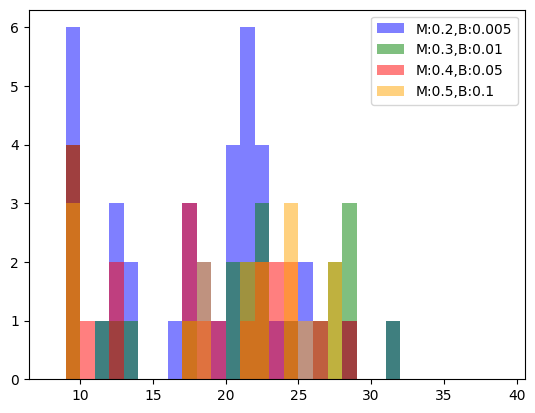

In [17]:
candidates1_df = candidates1_df.reset_index()
candidates2_df = candidates2_df.reset_index()
candidates3_df = candidates3_df.reset_index()
candidates4_df = candidates4_df.reset_index()
plt.hist(candidates1_df['whole_epitopes'].str.len(), bins=[i for i in range(8,35)], color='blue', alpha=0.5, label='M:0.2,B:0.005')
plt.hist(candidates2_df['whole_epitopes'].str.len(), bins=[i for i in range(8,40)], color='green', alpha=0.5, label='M:0.3,B:0.01')
plt.hist(candidates3_df['whole_epitopes'].str.len(), bins=[i for i in range(8,40)], color='red', alpha=0.5, label='M:0.4,B:0.05')
plt.hist(candidates4_df['whole_epitopes'].str.len(), bins=[i for i in range(8,40)], color='orange', alpha=0.5, label='M:0.5,B:0.1')
plt.legend()
plt.show()

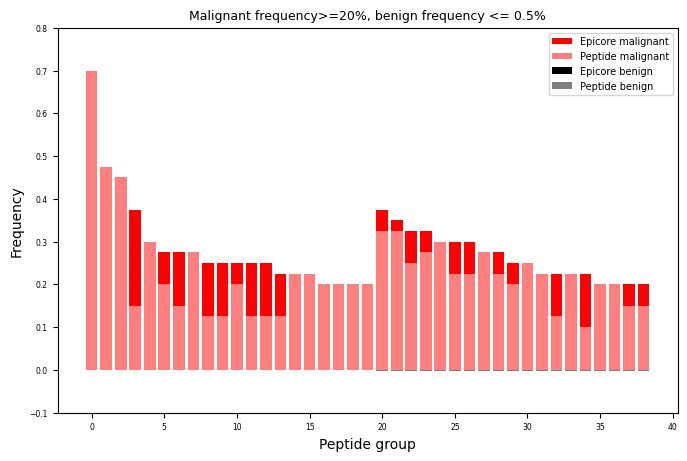

In [7]:
fig, ax = plt.subplots(1,1, figsize=(8,5))
candidates1_df = get_candidate_region(epicore_df, 0.2, 0.005)
plot_candidates(candidates1_df, ax)
ax.set_title('Malignant frequency>=20%, benign frequency <= 0.5%', fontdict={'fontsize':9})
ax.set_ylabel('Frequency')
ax.set_xlabel('Peptide group')
ax.tick_params(labelsize=5.5)
ax.set_ylim(-0.1,0.8)
plt.legend(fontsize=7)
plt.savefig('figures/single_candidates.svg')

Investigate HNSCC class2 warehouse peptides

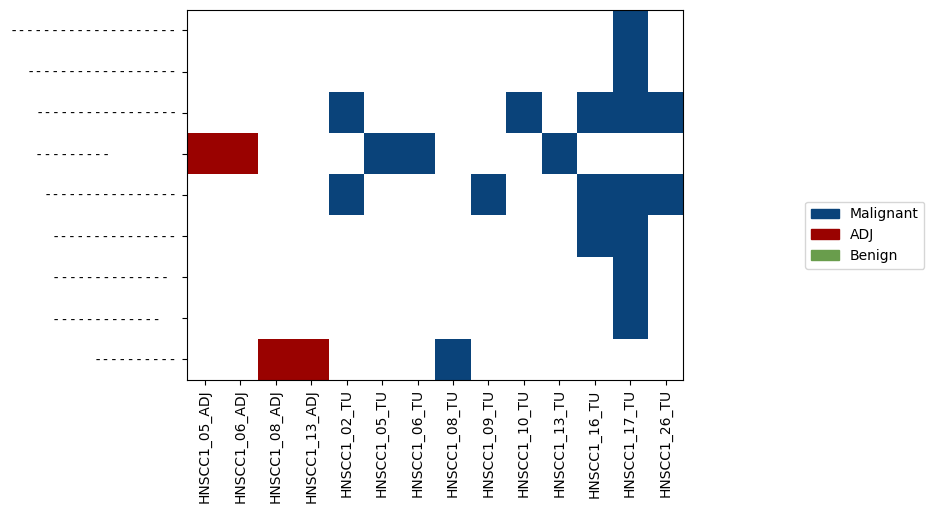

In [ ]:
# get whole group sequence of candidate 1
candidates1_df = candidates1_df.reset_index()
candidate1_entire = candidates1_df[candidates1_df['whole_epitopes'].str.contains('removed')].iloc[0]['whole_epitopes']
fig, ax = plt.subplots()
HNSCC_candidate_heatmap('class2_included/epitopes.csv', candidate1_entire, ax)
plt.savefig('figures/HNSCC_w1.svg', bbox_inches='tight')


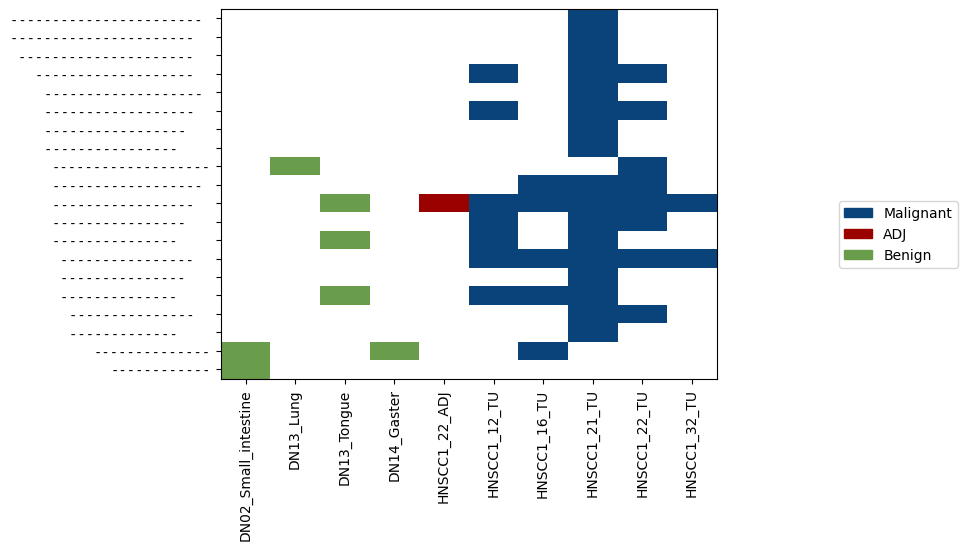

In [ ]:
epicore_df = epicore_df.reset_index()
candidate2_entire = epicore_df[epicore_df['whole_epitopes'].str.contains('removed')].iloc[0]['whole_epitopes']
fig, ax = plt.subplots()
HNSCC_candidate_heatmap('class2_included/epitopes.csv', candidate2_entire, ax)
plt.savefig('figures/HNSCC_w2.svg', bbox_inches='tight')

Investigate class1 warehouse candidates in class2.

In [ ]:
epicore_df = epicore_df.reset_index()
whole_epitopes = []
class1 = ['masked','masked','masked','masked','masked','masked','masked','masked']
for candidate in class1: 
    df = epicore_df[epicore_df['whole_epitopes'].str.contains(candidate)]
    if len(df)>0:
        whole_epitopes.append(df.iloc[0]['whole_epitopes'])

In [ ]:
# cell output deleted due to sensitive data
epicore_df[epicore_df['whole_epitopes'].isin(whole_epitopes)]

One class1 candidate is highly frequent in class2. Visualization of the peptide group of that candidate.

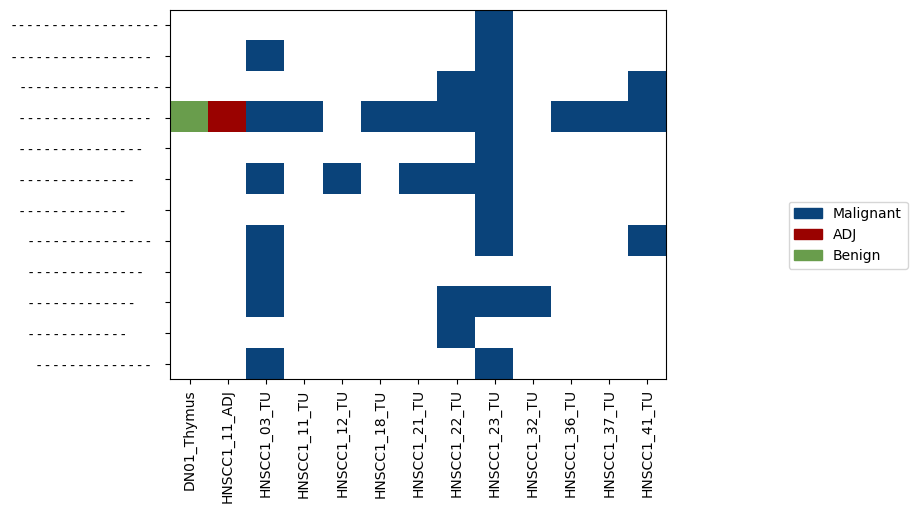

In [ ]:
fig, ax = plt.subplots()
HNSCC_candidate_heatmap('class2_included/epitopes.csv', 'masked', ax)
plt.savefig('figures/HNSCC_c1.svg', bbox_inches='tight')

The top ten candidates for malignant frequency >= 20% and benign frequency 0%

In [ ]:
# cell output deleted due to sensitive data
candidates1_df.sort_values(['benign_frequency_epicore','malignant_frequency_epicore'], ascending=[True, False]).head(10)

Visualization of some of the top candidates. 

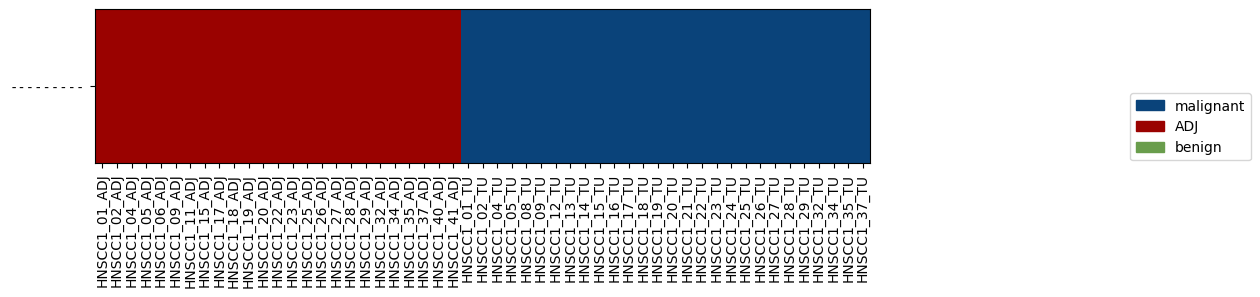

In [ ]:
fig, ax = plt.subplots(figsize=(10,2))
HNSCC_candidate_heatmap('class2_included/epitopes.csv', 'masked', ax)

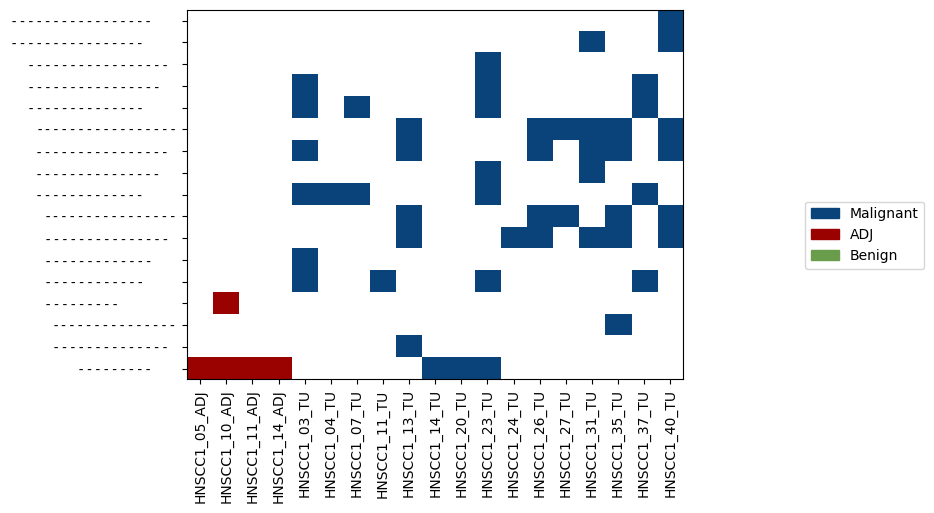

In [ ]:
fig, ax = plt.subplots()
HNSCC_candidate_heatmap('class2_included/epitopes.csv', 'masked', ax)
plt.savefig('figures/HNSCC_nopr_le.svg', bbox_inches='tight')

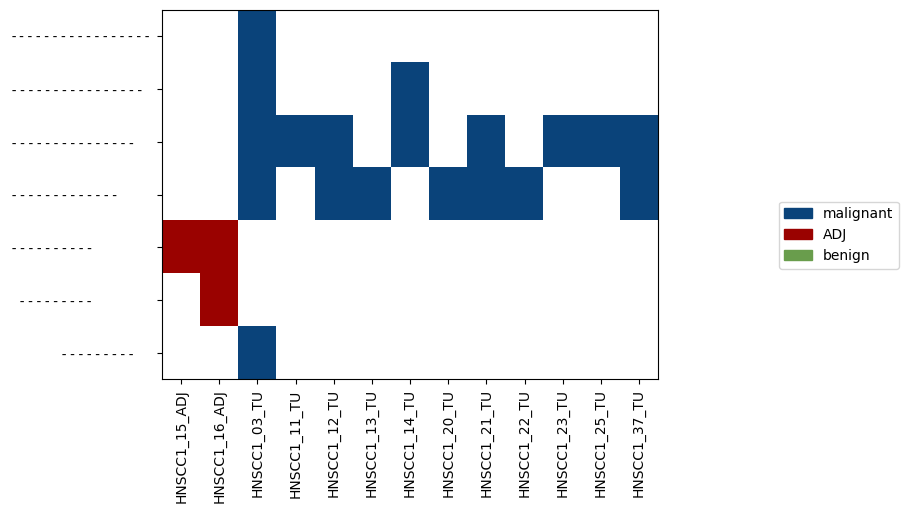

In [ ]:
fig, ax = plt.subplots()
HNSCC_candidate_heatmap('class2_included/epitopes.csv', 'masked', ax)
plt.savefig('figures/HNSCC_nopr_le.svg', bbox_inches='tight')

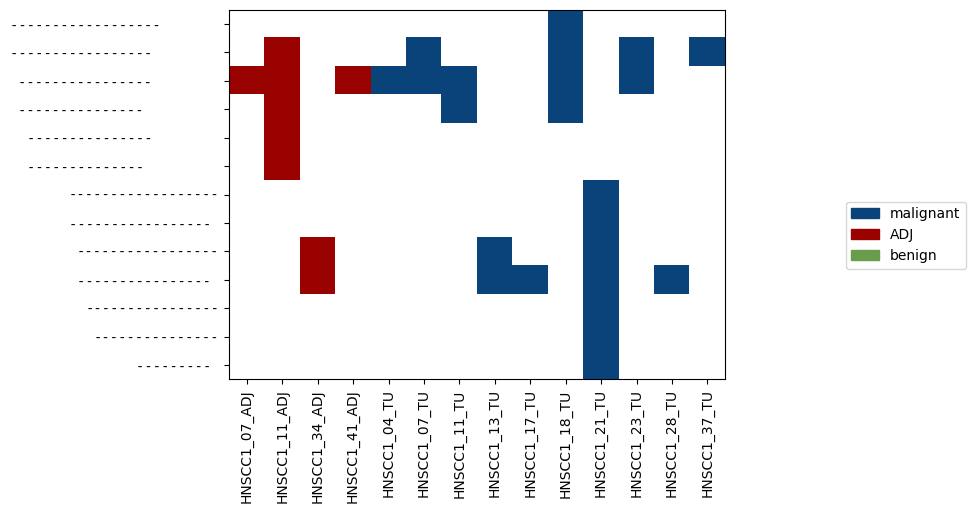

In [ ]:
fig, ax = plt.subplots()
HNSCC_candidate_heatmap('class2_included/epitopes.csv', 'masked', ax)

In [ ]:
epitopes_df = pd.read_csv('class2_included/epitopes.csv', index_col=[0])
group = epitopes_df[epitopes_df['whole_epitopes']=='masked'].iloc[0]
group_df = pd.DataFrame({'sequences':ast.literal_eval(group['grouped_peptides_sequence']), 'samples':ast.literal_eval(group['grouped_peptides_sample'])})
group_df = group_df[group_df['samples'].str.contains('TU')]
group_df = group_df.groupby('sequences').agg({'samples':lambda x: ','.join(x)})

In [ ]:
# cell output deleted due to sensitive data
# identify the rank of the peptide group on peptide and epicore level
df = candidates1_df.sort_values(['malignant_frequency', 'benign_frequency'], ascending=[False, True])
df['prev_malignant'] = df['malignant_frequency'].shift(-1)
df['rank'] = df.apply(lambda row: 1 if row['prev_malignant']!=row['malignant_frequency'] else 0, axis=1)
df['rank'] = df['rank'].cumsum()
df['rank'] = df['rank'].shift(1)
df.at[df.index[0],'rank'] = 0
df = df.sort_values('ratio')
df = df.sort_values(['malignant_frequency_epicore', 'benign_frequency_epicore'], ascending=[False, True])

# identify rank on peptide group level
df['prev_malignant'] = df['malignant_frequency_epicore'].shift(-1)
df['rank_epicore'] = df.apply(lambda row: 1 if row['prev_malignant']!=row['malignant_frequency_epicore'] else 0, axis=1)
df['rank_epicore'] = df['rank_epicore'].cumsum()
df['rank_epicore'] = df['rank_epicore'].shift(1)

# identify how many candidates have higher rank due to epicore
df[df['whole_epitopes']=='removed']

### Identify candidates and investigate chosen candidates - class1

In [31]:
# Create alle dict from HLA ligand atlas
base_url = 'http://hla-ligand-atlas.org/rel/2020.12/'
donors = pd.read_csv(base_url + 'donors.tsv.gz', sep='\t')
donor_alleles = donors.groupby('donor').agg({'hla_allele': lambda x: ';'.join(sorted([i for i in x if i[0] in ['A','B','C']]))})
allele_dict = dict(zip(donor_alleles.index, donor_alleles['hla_allele']))

with open('/mnt/volume/jana/thesis/data/allotype_annotation/alleles_Naomi_Nat_comms.json') as naomi_json:
    naomi_dict = json.load(naomi_json)

with open('/mnt/volume/jana/thesis/data/allotype_annotation/alleles_AD_Autopsy.json') as AD_json:
    AD_dict = json.load(AD_json)

allele_dict.update(naomi_dict)
allele_dict.update(AD_dict)

allele_dict = dict((key.split('-')[-1], value) for (key, value) in allele_dict.items())
class1_epitopes = pd.read_csv('class1_included/epitopes.csv', index_col=[0])
samples_all = class1_epitopes['grouped_peptides_sample'].apply(lambda cell: ast.literal_eval(cell)).explode().unique()
allele_dict = {sample: allele_dict[sample] if sample in allele_dict.keys() else (allele_dict[re.split(r'_|-',sample)[0]] if re.split(r'_|-', sample)[0] in allele_dict.keys() else None) for sample in samples_all}

In [32]:
allotypes_dict = allele_dict | allotypes_dict

In [ ]:
# cell output deleted due to sensitive data
# Identify the number of samples per allotype

for allotype in ['A*01', 'A*02', 'A*24', 'B*35', 'B*40']:
    print(f'{len([at for sample, at in allele_dict.items() if ((at and (allotype in at)) and ("HNSCC" not in sample))])} benign samples show the allotype {allotype}.')

#### A*01

In [34]:
A_01_df = compute_frequencies('class1_included/epitopes.csv', 'class1_peptides.csv', allotypes_dict, 'A*01')

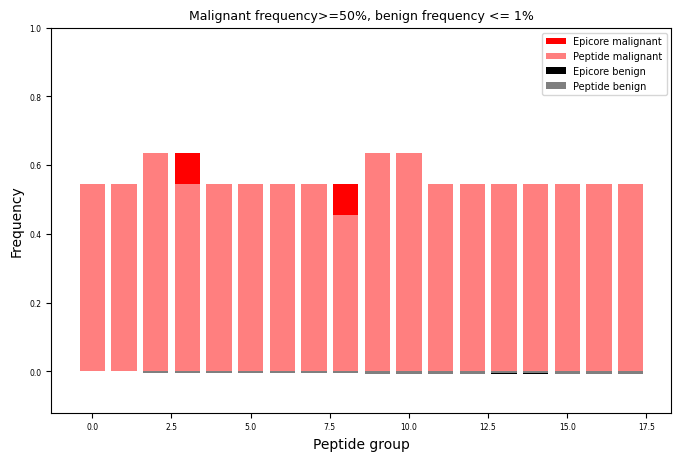

In [35]:
fig, ax = plt.subplots(1,1, figsize=(8,5))
candidates1_df = get_candidate_region(A_01_df, 0.5, 0.01)
plot_candidates(candidates1_df, ax)
ax.set_title('Malignant frequency>=50%, benign frequency <= 1%', fontdict={'fontsize':9})
ax.set_ylabel('Frequency')
ax.set_xlabel('Peptide group')
ax.tick_params(labelsize=5.5)
plt.legend(fontsize=7)
plt.savefig('figures/A01_candidates.svg')

A*02

In [36]:
A_02_df = compute_frequencies('class1_included/epitopes.csv', 'class1_peptides.csv', allotypes_dict, 'A*02')

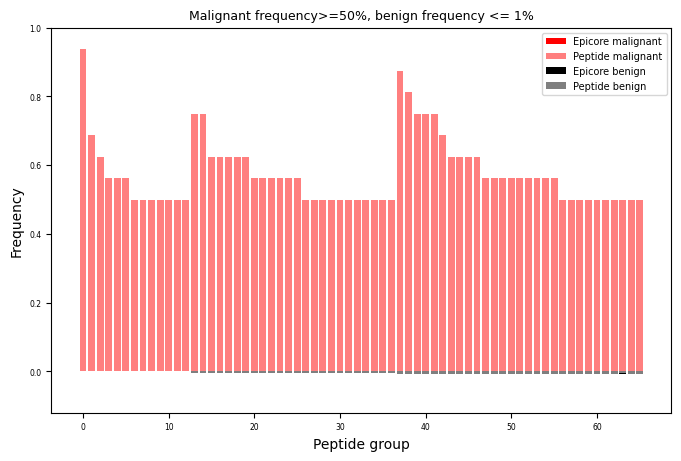

In [37]:
fig, ax = plt.subplots(1,1, figsize=(8,5))
candidates1_df = get_candidate_region(A_02_df, 0.5, 0.01)
plot_candidates(candidates1_df, ax)
ax.set_title('Malignant frequency>=50%, benign frequency <= 1%', fontdict={'fontsize':9})
ax.set_ylabel('Frequency')
ax.set_xlabel('Peptide group')
ax.tick_params(labelsize=5.5)
plt.legend(fontsize=7)
plt.savefig('figures/A02_candidates.svg')

A*24

In [38]:
A_24_df = compute_frequencies('class1_included/epitopes.csv', 'class1_peptides.csv', allotypes_dict, 'A*24')

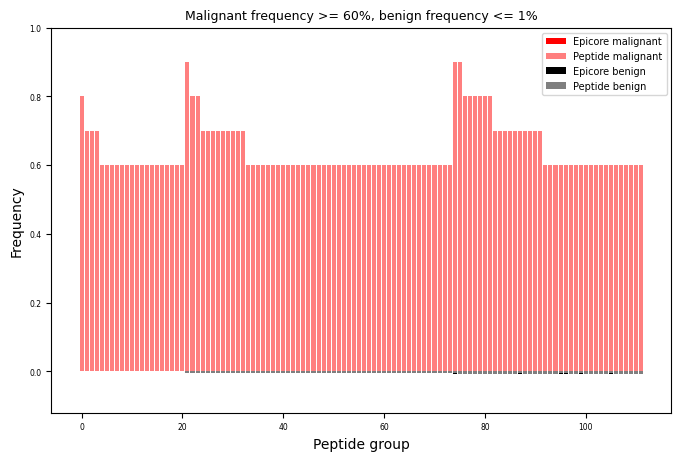

In [39]:
fig, ax = plt.subplots(1,1, figsize=(8,5))
candidates1_df = get_candidate_region(A_24_df, 0.6, 0.01)
plot_candidates(candidates1_df, ax)
ax.set_title('Malignant frequency >= 60%, benign frequency <= 1%', fontdict={'fontsize':9})
ax.set_ylabel('Frequency')
ax.set_xlabel('Peptide group')
ax.tick_params(labelsize=5.5)
plt.legend(fontsize=7)
plt.savefig('figures/A24_candidates.svg')

B*35

In [40]:
B_35_df = compute_frequencies('class1_included/epitopes.csv', 'class1_peptides.csv', allotypes_dict, 'B*35')

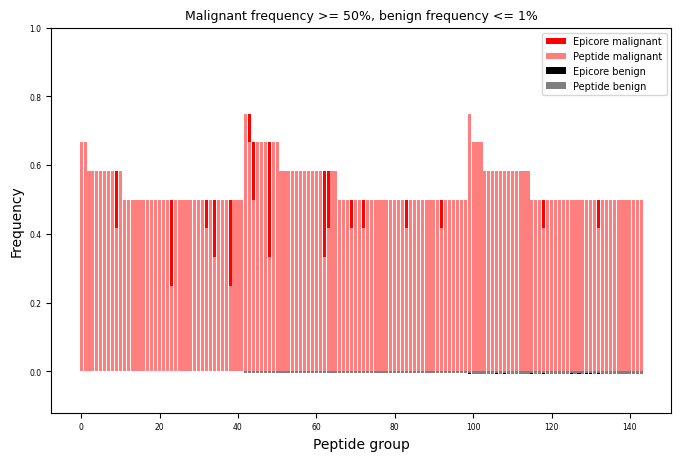

In [41]:
fig, ax = plt.subplots(1,1, figsize=(8,5))
candidates1_df = get_candidate_region(B_35_df, 0.5, 0.01)
plot_candidates(candidates1_df, ax)
ax.set_title('Malignant frequency >= 50%, benign frequency <= 1%', fontdict={'fontsize':9})
ax.set_ylabel('Frequency')
ax.set_xlabel('Peptide group')
ax.tick_params(labelsize=5.5)
plt.legend(fontsize=7)
plt.savefig('figures/B35_candidates.svg')

In [ ]:
# cell output deleted due to sensitive data
candidates1_df.sort_values('ratio').head(10)

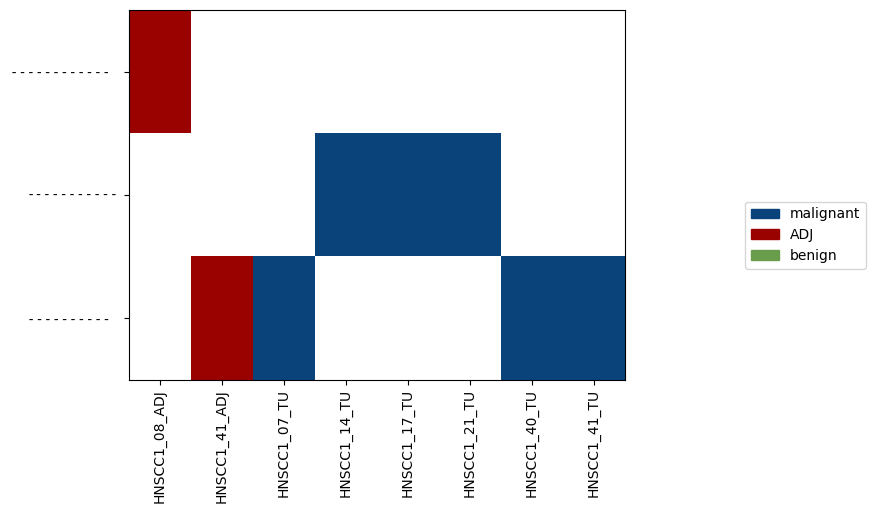

In [ ]:
fig, ax = plt.subplots()
HNSCC_candidate_heatmap('class1_included/epitopes.csv', 'masked', ax)

The additional row in the heatmap is from a different allotype.

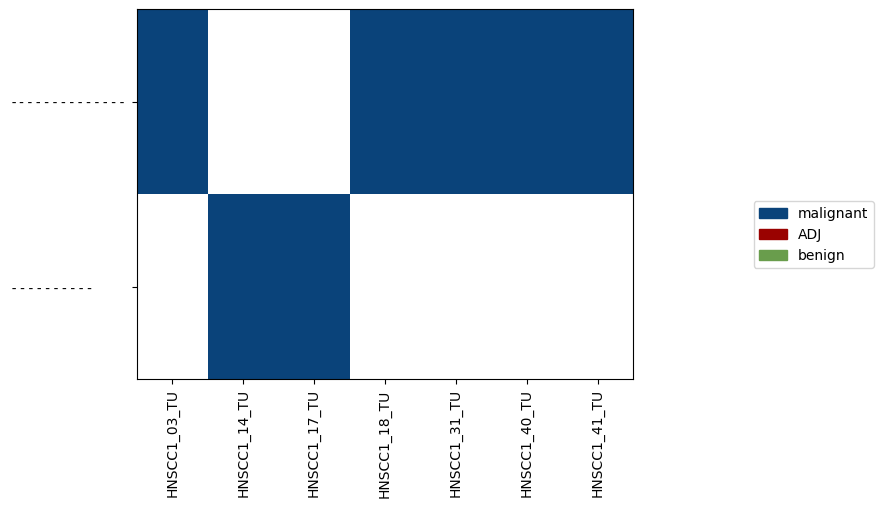

In [ ]:
fig, ax = plt.subplots()
HNSCC_candidate_heatmap('class1_included/epitopes.csv', 'masked', ax)

In [45]:
sequences = candidates1_df[candidates1_df['malignant_frequency_epicore']>candidates1_df['malignant_frequency']].sort_values('ratio').explode('grouped_peptides_sequence')['grouped_peptides_sequence'].unique()
pd.DataFrame({'sequence':sequences}).to_csv('epitopeprediction.tsv', index=False, sep='\t')
pd.DataFrame({'sample':['A'], 'alleles':['B*35:01;B*35:02;B*35:03;B*35:04'], 'mhc_class':['I'], 'filename':['epitopeprediction.tsv']}).to_csv('epitopeprediction_samplesheet.csv', index=False)

Run epitopeprediction with <br>
nextflow run nf-core/epitopeprediction -profile docker --input epitopeprediction_samplesheet.csv --outdir class1_HNSCC -r 3.1.0 --tools netmhcpan --netmhcpan_path /mnt/volume/jana/mhcquant-epitopeprediction/data/netMHCpan-4.1b.Linux.tar.gz --min_peptide_length_classI 8 --max_peptide_length_classII 15 --wide_format_output

In [ ]:
# cell output deleted due to sensitive data
# Analyze the prediction results
# check for how many peptide group 
predictions_df = pd.read_csv('class1_HNSCC/predictions/A.tsv', sep='\t')
candidates1_df = candidates1_df[candidates1_df['malignant_frequency_epicore']>candidates1_df['malignant_frequency']].reset_index()
candidates_exploded = candidates1_df.explode('grouped_peptides_sequence').reset_index()
predictions_df = pd.merge(predictions_df, candidates_exploded, left_on='sequence', right_on='grouped_peptides_sequence', how='outer')
predictions_df = predictions_df.drop_duplicates(['sequence', 'whole_epitopes'])
predictions_df.groupby('whole_epitopes').agg({'sequence':list, 'binder':list})

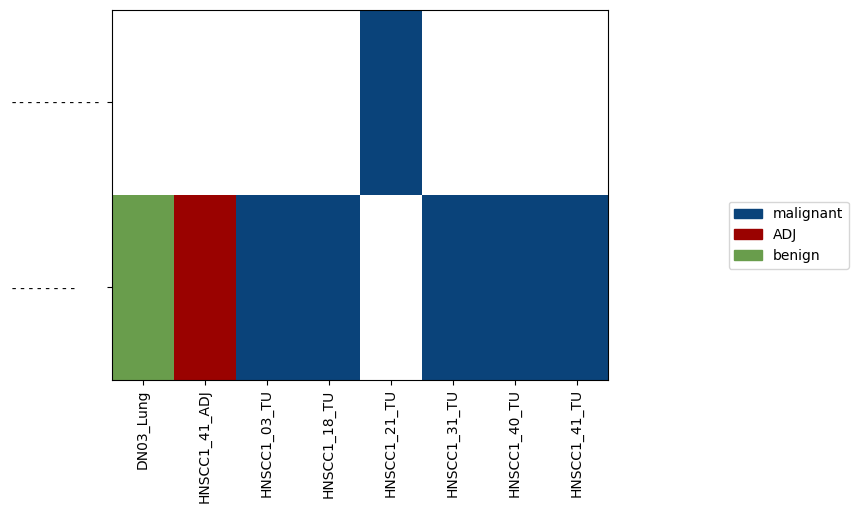

In [ ]:
fig, ax = plt.subplots()
HNSCC_candidate_heatmap('class1_included/epitopes.csv', 'masked', ax)
plt.savefig('figures/HNSCC_B35.svg', bbox_inches='tight')

In [48]:
# benign samples with the respective allotype 
[sample for sample, at in allele_dict.items() if (at and ('B*35' in at)) and ("HNSCC" not in sample)]

['DN12_Aorta',
 'DN02_Pancreas',
 'DN02_Myelon',
 'DN02_Brain',
 'DN12_Bladder',
 'DN03_Spleen',
 'DN03_Lung',
 'DN03_Liver',
 'DN02_Small_intestine',
 'DN12_Spleen',
 'DN12_Pancreas',
 'DN12_Cerebellum',
 'DN03_Small_intestine',
 'DN02_Muscle',
 'DN02_Kidney',
 'DN12_Kidney',
 'DN03_Esophagus',
 'DN09_Pancreas',
 'DN03_Cerebellum',
 'DN02_Spleen',
 'DN17_Gaster',
 'DN03_Gaster',
 'DN12_Bone_marrow',
 'DN17_Tongue',
 'DN17_Thyroid',
 'DN17_Spleen',
 'DN17_Small_intestine',
 'DN17_Liver',
 'DN17_Bone_marrow',
 'DN03_Thymus',
 'DN09_Brain',
 'DN17_Bladder',
 'DN09_Skin',
 'DN03_Testis',
 'DN17_Skin',
 'DN17_Lung',
 'DN17_Heart',
 'DN17_Gallbladder',
 'DN17_Brain',
 'DN17_Adrenal_gland',
 'DN281_Ovary',
 'DN12_Uterus',
 'DN12_Ovary',
 'DN12_Lung',
 'DN03_Brain',
 'DN17_Trachea',
 'DN17_Testis',
 'DN02_Testis',
 'DN03_Adrenal_gland',
 'DN12_Liver',
 'DN12_Esophagus',
 'DN09_Heart',
 'DN03_Skin',
 'DN03_Muscle',
 'DN03_Heart',
 'DN02_Thyroid',
 'DN03_Thyroid',
 'DN03_Aorta',
 'DN12_Heart',


B*40

In [49]:
B_40_df = compute_frequencies('class1_included/epitopes.csv', 'class1_peptides.csv', allotypes_dict, 'B*40')

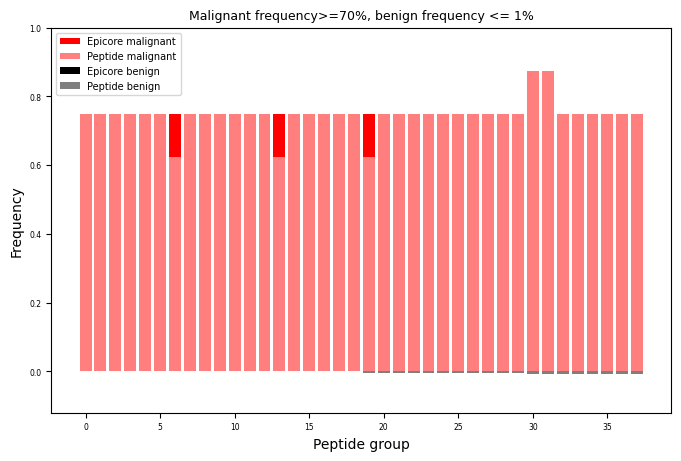

In [50]:
fig, ax = plt.subplots(1,1, figsize=(8,5))
candidates1_df = get_candidate_region(B_40_df, 0.7, 0.01)
plot_candidates(candidates1_df, ax)
ax.set_title('Malignant frequency>=70%, benign frequency <= 1%', fontdict={'fontsize':9})
ax.set_ylabel('Frequency')
ax.set_xlabel('Peptide group')
ax.tick_params(labelsize=5.5)
plt.legend(fontsize=7)
plt.savefig('figures/B40_candidates.svg')

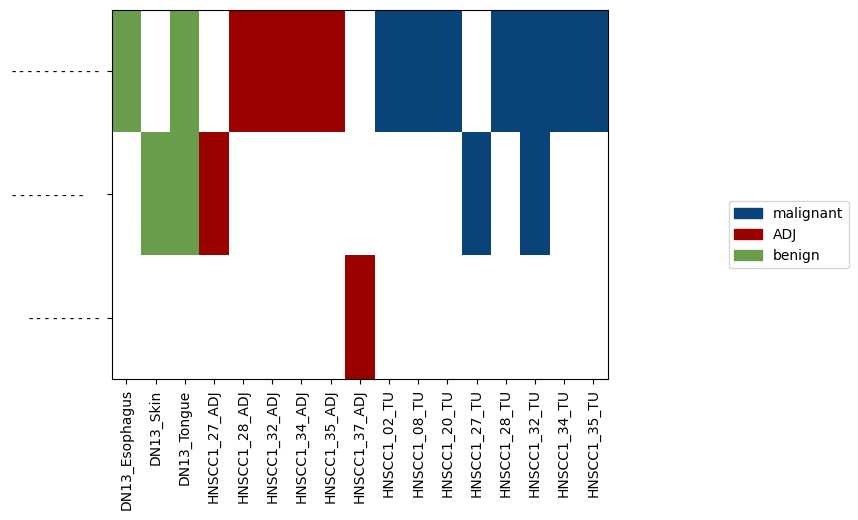

In [ ]:
fig, ax = plt.subplots()
HNSCC_candidate_heatmap('class1_included/epitopes.csv', 'masked', ax)